Heart Disease Predictor 

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [42]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA & Data Cleaning

In [43]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

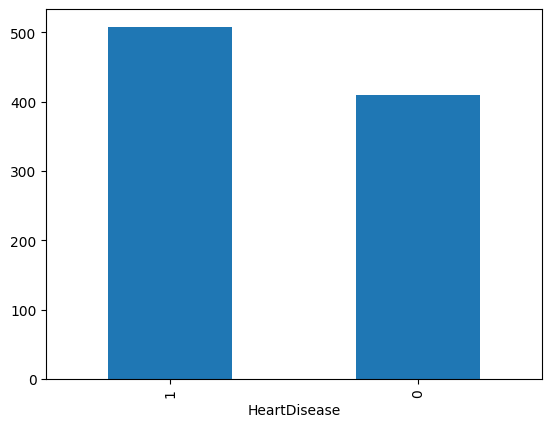

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar')

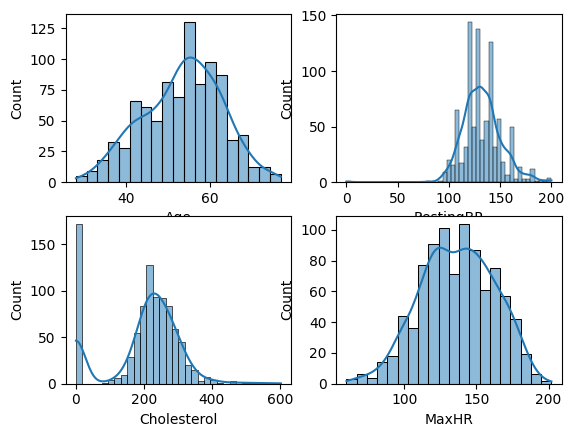

In [47]:
def numeric(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde= True)

numeric('Age', 1)
numeric('RestingBP', 2)
numeric('Cholesterol', 3)
numeric('MaxHR', 4)

In [45]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [48]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

In [49]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)

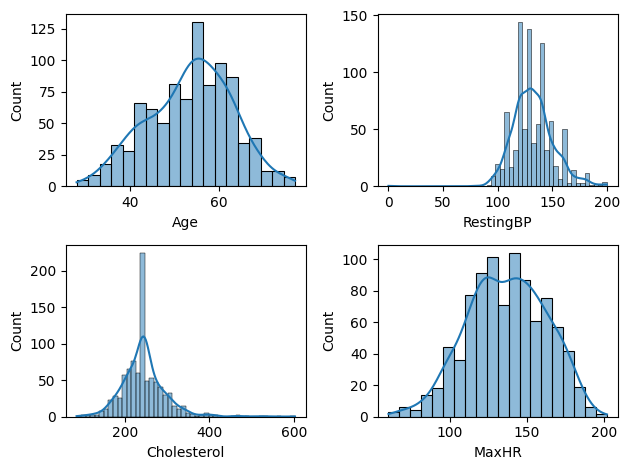

In [51]:
def numeric(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde= True)
    plt.tight_layout()
    
numeric('Age', 1)
numeric('RestingBP', 2)
numeric('Cholesterol', 3)
numeric('MaxHR', 4)

In [52]:
resting_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

In [53]:
df['RestingBP'] = df['RestingBP'].replace(0, resting_mean)

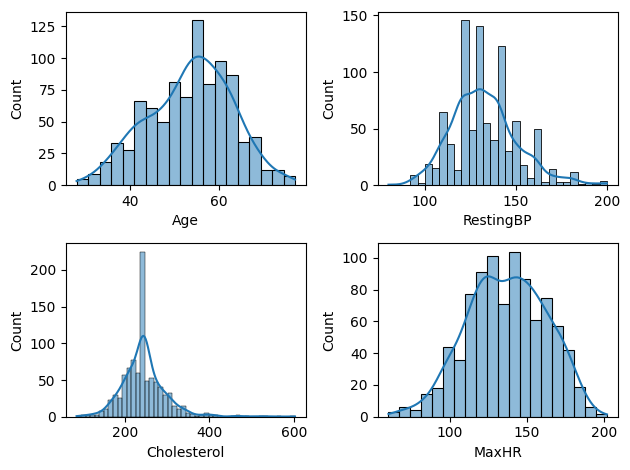

In [54]:
def numeric(var, num):
    plt.subplot(2,2, num)
    sns.histplot(df[var], kde= True)
    plt.tight_layout()
    
numeric('Age', 1)
numeric('RestingBP', 2)
numeric('Cholesterol', 3)
numeric('MaxHR', 4)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 86.2 KB


<Axes: xlabel='Sex', ylabel='count'>

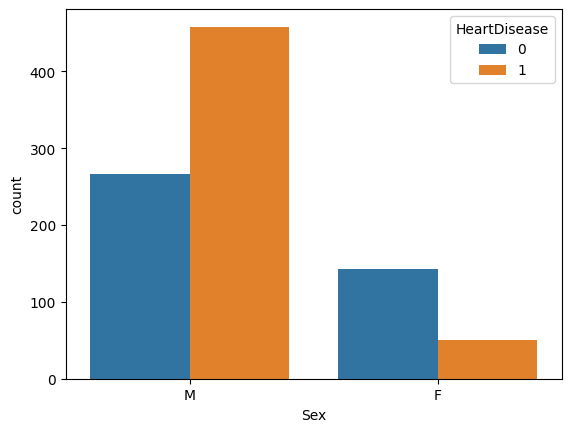

In [66]:
sns.countplot(x= df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

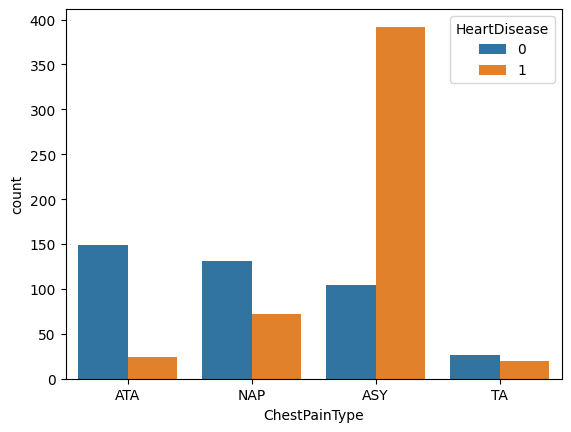

In [65]:
sns.countplot(x= df['ChestPainType'], hue= df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

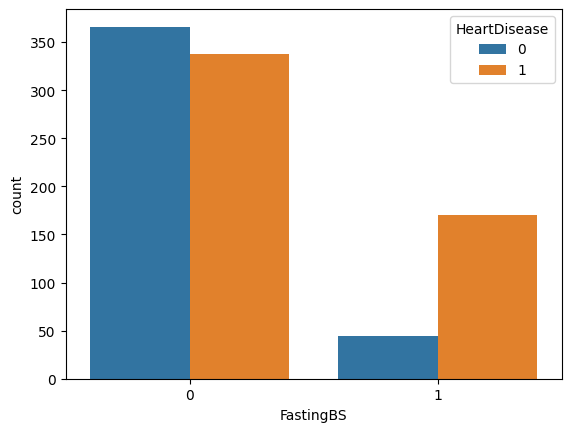

In [67]:
sns.countplot(x = df['FastingBS'], hue= df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

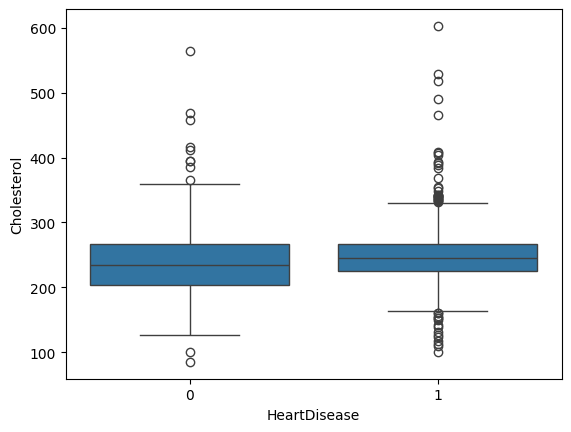

In [70]:
sns.boxplot(x = 'HeartDisease',y = 'Cholesterol', data = df)

<Axes: >

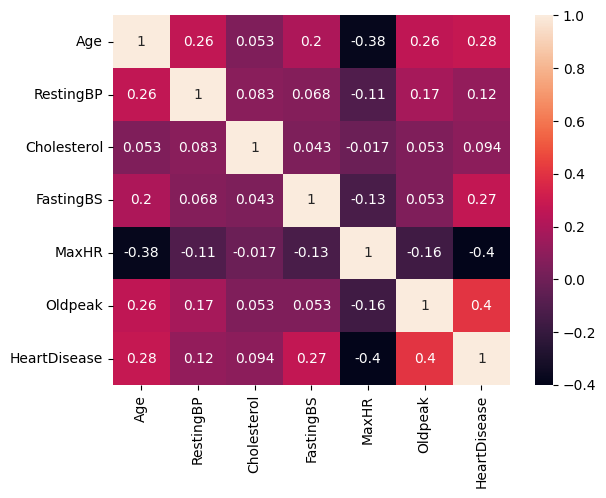

In [71]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data Preprocessing 

In [72]:
df_encode = pd.get_dummies(df,
                           drop_first=True,
                           dtype=int)

In [73]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [75]:
from sklearn.preprocessing import StandardScaler
numeric_clm = ['Age', 'RestingBP', "Cholesterol", 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
df_encode[numeric_clm] = scaler.fit_transform(df_encode[numeric_clm])

df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.293283,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.357094,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.293283,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.832432,1,0,1,0,0,0,0,0,1,0
